In [1]:
%matplotlib widget
import torch
import warnings
import os
import copy
import subprocess
import shlex
import matplotlib.pyplot as plt
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
from torch.profiler import profile,  ProfilerActivity

os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from diffSPH.sampling import buildDomainDescription
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.integration import getIntegrator
from diffSPH.util import volumeToSupport
from diffSPH.boundary import sampleDomainSDF
from diffSPH.kernels import Kernel_Scale
from diffSPH.sdf import getSDF, sdfFunctions, operatorDict, sampleSDF
from diffSPH.regions import buildRegion, filterRegion, plotRegions
from diffSPH.modules.timestep import computeTimestep
from diffSPH.schemes.initializers import initializeSimulation, updateBodyParticles
from diffSPH.schemes.deltaSPH import deltaPlusSPHScheme, DeltaPlusSPHSystem
from diffSPH.schema import getSimulationScheme
from diffSPH.enums import *
from exampleUtil import setupExampleSimulation, runSimulation, postProcess
from diffSPH.sampling import sampleDivergenceFreeNoise
import math
from diffSPH.sampling import sampleDivergenceFreeNoise
from diffSPH.modules.particleShifting import solveShifting, shuffleParticles
import numpy as np
import pandas as pd

,Time[s],Pressure[mbar],Position_smooth_splines [deg],Velocity[deg\s],Aceleration[deg\s2],Position_original [deg]
0,0.00000,0.119914,1.387779e-17,2.775558e-16,15.428041,1.143341e-09
1,0.00005,0.213180,1.929147e-08,7.717871e-04,15.443441,1.194000e-03
2,0.00010,0.133238,7.719154e-08,1.544344e-03,15.458842,1.194000e-03
3,0.00015,-0.053295,1.737387e-07,2.317671e-03,15.474243,1.194000e-03
4,0.00020,0.159885,3.089715e-07,3.091769e-03,15.489644,1.194000e-03
...,...,...,...,...,...,...
121596,6.07980,-0.626217,-5.980536e-02,2.141933e+01,-0.437980,-5.373700e-02
121597,6.07985,-0.932664,-5.873440e-02,2.141931e+01,-0.465957,-5.254300e-02
121598,6.07990,-0.692836,-5.766343e-02,2.141929e+01,-0.493934,-5.134900e-02
121599,6.07995,-0.652865,-5.659247e-02,2.141926e+01,-0.521910,-5.015500e-02


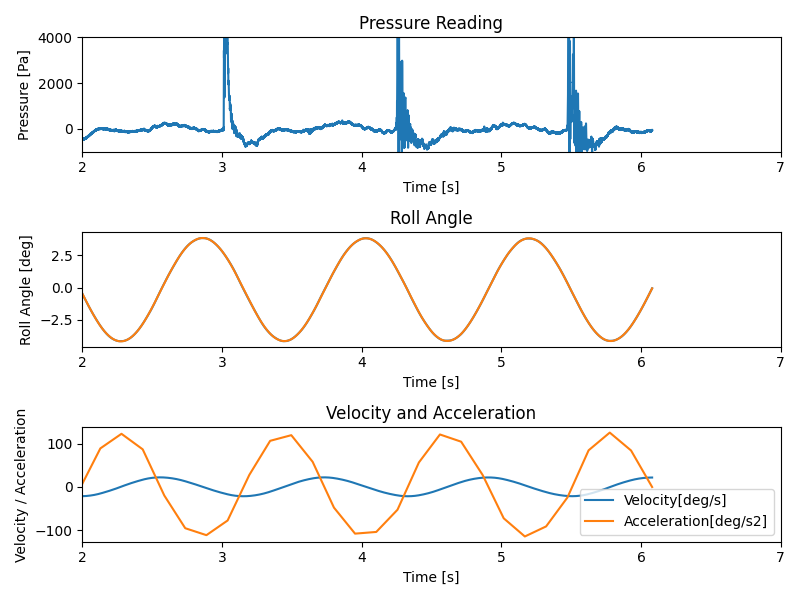

In [8]:

rollHistory = pd.read_csv('SPHERIC_TestCase10/data_files/roof_water_1x.txt', sep='\t')
# rollHistory = pd.read_csv('SPHERIC_TestCase10/data_files/lateral_water_1x.txt', sep='\t')

display(rollHistory)

fig, axis = plt.subplots(3, 1, figsize=(8, 6), squeeze=False)

dt = rollHistory['Time[s]'][1] - rollHistory['Time[s]'][0]

rollTimes = rollHistory['Time[s]'].to_numpy()
pressure = rollHistory['Pressure[mbar]'].to_numpy()
pressurePa = pressure * 100  # convert to Pa


positionOriginal = rollHistory['Position_original [deg]'].to_numpy()
positionSmooth = rollHistory['Position_smooth_splines [deg]'].to_numpy()

velocity = rollHistory['Velocity[deg\\s]'].to_numpy()
acceleration = rollHistory['Aceleration[deg\\s2]'].to_numpy()

axis[0,0].plot(rollTimes, pressurePa)
axis[0,0].set_ylabel('Pressure [Pa]')
axis[0,0].set_title('Pressure Reading')

axis[1,0].plot(rollTimes, positionOriginal)
axis[1,0].plot(rollTimes, positionSmooth)
axis[1,0].set_ylabel('Roll Angle [deg]')
axis[1,0].set_title('Roll Angle')

axis[2,0].plot(rollTimes, velocity, label='Velocity[deg/s]')
axis[2,0].plot(rollTimes, acceleration, label='Acceleration[deg/s2]')
axis[2,0].set_ylabel('Velocity / Acceleration')
axis[2,0].set_title('Velocity and Acceleration')
axis[2,0].legend()  

for ax in axis.flatten():
    ax.set_xlabel('Time [s]')
    ax.set_xlim(2,7)
axis[0,0].set_ylim(-1000, 4000)

fig.tight_layout()